# Phase 4 submission: Multiphase Training using Harvard Dataset
# Areeba Naveed (27100239) and Haider Wajahat (27100252) 

This is our basic implementation of multi-class liver/tumor segmentation model using all available multiphase inputs.

Basic go through for this notebook:
- It uses **all four phases** in fixed order: `NC`, `AP`, `PVP`, `DP`
- It builds a **3-class target**: `0=background`, `1=liver`, `2=tumor`
- It perfroms liver/tumor segmentation and reports **both liver Dice and tumor Dice**

### Runtime Setup and Package Installation

This cell mounts Google Drive and installs the external Python packages required for the notebook. It prepares the Colab environment so the dataset, preprocessing utilities, and training pipeline can run without dependency issues.

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as e:
    print('Drive mount skipped or already mounted:', e)

import subprocess
import sys

subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q', 'nibabel', 'scipy', 'scikit-image', 'matplotlib', 'tqdm'],
    check=False,
)

print('Dependency install step finished.')


Mounted at /content/drive
Dependency install step finished.


## Import Libraries

This cell imports all required libraries for file handling, medical image loading, preprocessing, visualization, deep learning, and evaluation. These imports support the full pipeline from raw TAR files to final segmentation results.

In [ ]:
import os
import json
import tarfile
import shutil
import random
import time
from pathlib import Path
from collections import defaultdict

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms.functional as TF

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

MODEL_VARIANT = 'baseline'
NUM_CLASSES = 3   # 0=background, 1=liver, 2=tumor
IN_CHANNELS = 4
IMG_SIZE = 256
BATCH_SIZE = 8
NUM_WORKERS = 2
NUM_EPOCHS = 20
LR = 1e-4
VAL_FRAC = 0.15
TEST_FRAC = 0.15
PHASE_DROPOUT_PROB = 0.20
MAX_TARS = 50
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Use your MyDrive shortcut folder as the single source of truth
MYDRIVE_ROOT = '/content/drive/MyDrive'
TAR_SOURCE_DIR = '/content/drive/MyDrive/v_download'

# Stage TARs and all heavy processing locally in the runtime
WORK_ROOT = '/content/harvard_multiphase_work'
LOCAL_TAR_ROOT = os.path.join(WORK_ROOT, 'local_tars')
EXTRACT_ROOT = os.path.join(WORK_ROOT, 'extracted_patients')
CACHE_ROOT = os.path.join(WORK_ROOT, 'processed_cache_50_multiclass')
MULTI_CACHE = os.path.join(CACHE_ROOT, 'multiphase_mc_slices_50')
ARTIFACT_DIR = os.path.join(CACHE_ROOT, 'training_artifacts')
CACHE_MANIFEST_PATH = os.path.join(MULTI_CACHE, 'cache_manifest.json')

# Optional export folder on Drive for copying final results later
DRIVE_EXPORT_ROOT = '/content/drive/MyDrive/MCT_LTDiag/final_exports'

PHASE_ORDER = ['nc', 'ap', 'pvp', 'dp']
VALID_EXTS = ('.nii', '.nii.gz')

Path(WORK_ROOT).mkdir(parents=True, exist_ok=True)
Path(LOCAL_TAR_ROOT).mkdir(parents=True, exist_ok=True)
Path(EXTRACT_ROOT).mkdir(parents=True, exist_ok=True)
Path(MULTI_CACHE).mkdir(parents=True, exist_ok=True)
Path(ARTIFACT_DIR).mkdir(parents=True, exist_ok=True)

print('Device         :', DEVICE)
print('MODEL_VARIANT  :', MODEL_VARIANT)
print('NUM_CLASSES    :', NUM_CLASSES)
print('MYDRIVE_ROOT   :', MYDRIVE_ROOT)
print('TAR_SOURCE_DIR :', TAR_SOURCE_DIR)
print('Source exists  :', os.path.exists(TAR_SOURCE_DIR))
print('WORK_ROOT      :', WORK_ROOT)
print('LOCAL_TAR_ROOT :', LOCAL_TAR_ROOT)
print('MULTI_CACHE    :', MULTI_CACHE)
print('ARTIFACT_DIR   :', ARTIFACT_DIR)


Device         : cuda
MODEL_VARIANT  : baseline
NUM_CLASSES    : 3
MYDRIVE_ROOT   : /content/drive/MyDrive
TAR_SOURCE_DIR : /content/drive/MyDrive/v_download
Source exists  : True
WORK_ROOT      : /content/harvard_multiphase_work
LOCAL_TAR_ROOT : /content/harvard_multiphase_work/local_tars
MULTI_CACHE    : /content/harvard_multiphase_work/processed_cache_50_multiclass/multiphase_mc_slices_50
ARTIFACT_DIR   : /content/harvard_multiphase_work/processed_cache_50_multiclass/training_artifacts


### Directory Management Utilities

This cell defines helper functions for creating and resetting working directories. These folders are used to store temporary TAR copies, extracted patient data, cached `.npz` slices, and model artifacts such as checkpoints and training history.

In [ ]:
#Create a directory if it does not already exist and return the path.
def ensure_dir(path):
    Path(path).mkdir(parents=True, exist_ok=True)
    return path

#Prepare all local runtime folders used for staged TARs, extraction, cache files, and artifacts.
def reset_local_workdirs():
    ensure_dir(WORK_ROOT)
    ensure_dir(LOCAL_TAR_ROOT)
    ensure_dir(EXTRACT_ROOT)
    ensure_dir(MULTI_CACHE)
    ensure_dir(ARTIFACT_DIR)

reset_local_workdirs()
print('Local working directories are ready.')


Local working directories are ready.


## Drive Access and TAR File Discovery

This cell defines helper functions for mounting Google Drive when needed and recursively locating TAR files from the configured dataset directory. This ensures that the Harvard dataset files can be accessed reliably during long Colab sessions.

In [ ]:
#Mount or remount Google Drive so the TAR shortcut folder remains readable during long runs.
def mount_drive_if_needed(force=False):
    try:
        from google.colab import drive as colab_drive
        colab_drive.mount('/content/drive', force_remount=force)
    except Exception as e:
        print('Drive mount helper:', e)



#Recursively collect TAR files from the configured source directory.
def find_tar_files(root_dir):
    tar_paths = []
    for root, _, files in os.walk(root_dir):
        for f in files:
            if f.lower().endswith('.tar') or f.lower().endswith('.tar.gz'):
                tar_paths.append(os.path.join(root, f))
    return sorted(tar_paths)


#Copy one TAR from Drive to local runtime with retry logic because Drive mounts can disconnect mid-copy.
def safe_copy_tar(src_path, dst_path, max_retries=4, sleep_seconds=3):
    for attempt in range(1, max_retries + 1):
        try:
            if os.path.exists(dst_path) and os.path.getsize(dst_path) > 0:
                try:
                    if os.path.getsize(src_path) == os.path.getsize(dst_path):
                        return dst_path
                except Exception:
                    pass

            shutil.copy2(src_path, dst_path)
            if not os.path.exists(dst_path) or os.path.getsize(dst_path) == 0:
                raise OSError(f'Local copy failed for {dst_path}')
            return dst_path
        except Exception as e:
            if os.path.exists(dst_path):
                try:
                    os.remove(dst_path)
                except Exception:
                    pass

            if attempt == max_retries:
                raise

            print(f'Copy retry {attempt}/{max_retries - 1} for {os.path.basename(src_path)} due to: {e}')
            time.sleep(sleep_seconds)
            mount_drive_if_needed(force=True)

mount_drive_if_needed(force=False)
all_source_tar_paths = find_tar_files(TAR_SOURCE_DIR)
tar_source_paths = all_source_tar_paths[:MAX_TARS]

print('Source root            :', TAR_SOURCE_DIR)
print('Available source TARs  :', len(all_source_tar_paths))
print('Selected source TARs   :', len(tar_source_paths))
print('First 5 source TARs    :')
for p in tar_source_paths[:5]:
    print(' ', p)

if len(tar_source_paths) < MAX_TARS:
    raise RuntimeError(
        f'Expected at least {MAX_TARS} TAR files in {TAR_SOURCE_DIR}, found {len(tar_source_paths)}.'
    )

local_tar_paths = []
for i, src_path in enumerate(tar_source_paths, start=1):
    dst_path = os.path.join(LOCAL_TAR_ROOT, os.path.basename(src_path))
    print(f'[{i:02d}/{len(tar_source_paths)}] Staging {os.path.basename(src_path)}')
    safe_copy_tar(src_path, dst_path)
    local_tar_paths.append(dst_path)

tar_paths = list(local_tar_paths)
tar_files = [os.path.basename(p) for p in tar_paths]

print('Local TAR root         :', LOCAL_TAR_ROOT)
print('Staged local TARs      :', len(local_tar_paths))
print('First 5 local TARs     :')
for p in local_tar_paths[:5]:
    print(' ', p)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Source root            : /content/drive/MyDrive/v_download
Available source TARs  : 317
Selected source TARs   : 50
First 5 source TARs    :
  /content/drive/MyDrive/v_download/230218a1.tar
  /content/drive/MyDrive/v_download/230218a10.tar
  /content/drive/MyDrive/v_download/230218a2.tar
  /content/drive/MyDrive/v_download/230218a3.tar
  /content/drive/MyDrive/v_download/230218a4.tar
[01/50] Staging 230218a1.tar
[02/50] Staging 230218a10.tar
[03/50] Staging 230218a2.tar
[04/50] Staging 230218a3.tar
Copy retry 1/3 for 230218a3.tar due to: [Errno 107] Transport endpoint is not connected
Mounted at /content/drive
[05/50] Staging 230218a4.tar
[06/50] Staging 230218a5.tar
[07/50] Staging 230218a6.tar
[08/50] Staging 230218a7.tar
[09/50] Staging 230218a8.tar
[10/50] Staging 230218a9.tar
[11/50] Staging 230218b1.tar
[12/50] Staging 230218b10.tar
[13/50] Staging 2302

## File Parsing, Phase Identification, and Patient Extraction

This cell defines the logic used to identify segmentation files, detect CT phase names, and extract patient TAR archives. It forms the basis for correctly matching the four phases and corresponding masks before preprocessing begins.

In [ ]:
SEG_KEYWORDS = ['seg', 'mask', 'label', 'annotation', 'contour', 'tumor', 'lesion', 'gt']
PHASE_KEYWORDS = {
    'nc':  ['_nc', 'noncontrast', 'non-contrast', 'plain', ' nc', 'nc.'],
    'ap':  ['_ap', 'arterial', ' art', 'art.', ' ap', 'ap.'],
    'pvp': ['_pvp', 'portal', 'venous', ' pv', 'pvp.'],
    'dp':  ['_dp', 'delay', 'delayed', 'equilibrium', ' dp', 'dp.'],
}

#Extract one patient TAR into a temporary local folder for inspection or cache generation
def extract_one_tar(tar_path, extract_root=EXTRACT_ROOT):
    tar_name = os.path.basename(tar_path)
    patient_name = tar_name.replace('.tar.gz', '').replace('.tar', '')
    patient_path = os.path.join(extract_root, patient_name)

    if os.path.exists(patient_path):
        shutil.rmtree(patient_path)
    os.makedirs(patient_path, exist_ok=True)

    mode = 'r:gz' if tar_name.endswith('.tar.gz') else 'r'
    with tarfile.open(tar_path, mode) as tar:
        tar.extractall(path=patient_path, filter='data')

    return patient_name, patient_path


#Remove a temporary extracted patient folder to keep runtime storage under control.
def cleanup_patient(patient_path):
    if patient_path is not None and os.path.exists(patient_path):
        shutil.rmtree(patient_path)


#Collect all NIfTI files under the extracted patient tree.
def find_all_nifti_files(patient_path):
    found = []
    for root, _, files in os.walk(patient_path):
        for f in files:
            lower = f.lower()
            if lower.endswith(VALID_EXTS):
                found.append(os.path.join(root, f))
    return sorted(found)


#Heuristically identify whether a file is a segmentation/annotation file.
def is_seg_file(path):
    name = os.path.basename(path).lower()
    return any(k in name for k in SEG_KEYWORDS)


#Infer the CT phase label from the filename using dataset-specific naming patterns.
def infer_phase(path):
    name = os.path.basename(path).lower()
    for phase, keys in PHASE_KEYWORDS.items():
        if any(k in name for k in keys):
            return phase
    if 'portal' in name or 'venous' in name:
        return 'pvp'
    if 'arter' in name:
        return 'ap'
    if 'delay' in name or 'equilibrium' in name:
        return 'dp'
    if 'non' in name or 'plain' in name:
        return 'nc'
    return None


#Separate tumor and liver masks from the extracted segmentation files.
def identify_masks(seg_candidates):
    tumor_mask = None
    liver_mask = None
    for p in seg_candidates:
        name = os.path.basename(p).lower()
        if 'liver' in name and 'mask' in name:
            liver_mask = p
        elif ('tumor' in name or 'lesion' in name or 'mask_pvp' in name or name.startswith('mask')) and 'liver' not in name:
            tumor_mask = p
    return tumor_mask, liver_mask


#Organize one extracted patient into phase images, masks, and unassigned files.
def group_patient_files(patient_path):
    files = find_all_nifti_files(patient_path)
    seg_candidates = [p for p in files if is_seg_file(p)]
    img_candidates = [p for p in files if not is_seg_file(p)]

    tumor_mask, liver_mask = identify_masks(seg_candidates)
    phase_map = {}
    unassigned = []

    for p in img_candidates:
        phase = infer_phase(p)
        if phase is None:
            unassigned.append(p)
        else:
            phase_map[phase] = p

    return {
        'all_files': files,
        'tumor_mask': tumor_mask,
        'liver_mask': liver_mask,
        'phase_map': phase_map,
        'unassigned_images': unassigned,
    }


#Load a medical volume with nibabel and return it as a NumPy array.
def load_volume(path):
    return nib.load(path).get_fdata()


#Print a quick human-readable summary of one patient TAR to verify file mapping.
def summarize_patient(tar_name):
    patient_path = None
    try:
        patient_name, patient_path = extract_one_tar(tar_name)
        info = group_patient_files(patient_path)
        print('Patient:', patient_name)
        print('Tumor mask:', os.path.basename(info['tumor_mask']) if info['tumor_mask'] else None)
        print('Liver mask:', os.path.basename(info['liver_mask']) if info['liver_mask'] else None)
        print('Phase map:')
        for k in PHASE_ORDER:
            print(f'  {k}:', os.path.basename(info['phase_map'][k]) if k in info['phase_map'] else None)
        print('Unassigned images:', [os.path.basename(p) for p in info['unassigned_images']])
        return patient_name, info
    finally:
        cleanup_patient(patient_path)

Printing summaries for a few sample TAR files to verify that the notebook is reading the dataset correctly. It helps confirm that phase discovery, file organization, and patient-level contents are being interpreted as expected.

In [ ]:
for tar_path in tar_paths[:3]:
    summarize_patient(tar_path)
    print('-' * 80)

Patient: 230218a1
Tumor mask: mask_pvp.nii.gz
Liver mask: liver_mask_pvp.nii.gz
Phase map:
  nc: nc.nii.gz
  ap: art.nii.gz
  pvp: pvp.nii.gz
  dp: delay.nii.gz
Unassigned images: []
--------------------------------------------------------------------------------
Patient: 230218a10
Tumor mask: mask_pvp.nii.gz
Liver mask: liver_mask_pvp.nii.gz
Phase map:
  nc: nc.nii.gz
  ap: art.nii.gz
  pvp: pvp.nii.gz
  dp: delay.nii.gz
Unassigned images: []
--------------------------------------------------------------------------------
Patient: 230218a2
Tumor mask: mask_pvp.nii.gz
Liver mask: liver_mask_pvp.nii.gz
Phase map:
  nc: nc.nii.gz
  ap: art.nii.gz
  pvp: pvp.nii.gz
  dp: delay.nii.gz
Unassigned images: []
--------------------------------------------------------------------------------


### CT Normalization, Resizing, and Sample Visualization Functions


This cell defines the preprocessing functions used to normalize CT intensities, resize slices to a fixed training shape, and visualize patient data. These steps standardize the inputs before they are converted into cached multi-phase training samples.

In [ ]:
#Clip and normalize CT intensities to a stable learning range.
def normalize_ct(vol, clip_min=-200, clip_max=250):
    vol = np.clip(vol, clip_min, clip_max)
    vol = (vol - clip_min) / (clip_max - clip_min + 1e-8)
    return vol.astype(np.float32)


#Resize a 2D image or mask slice to the model input size.
def resize_2d(arr, size=IMG_SIZE, is_mask=False):
    arr = arr.astype(np.float32)
    zoom_h = size / arr.shape[0]
    zoom_w = size / arr.shape[1]
    order = 0 if is_mask else 1
    out = zoom(arr, (zoom_h, zoom_w), order=order)
    if is_mask:
        out = np.rint(out).astype(np.uint8)
    return out


#Merge liver and tumor labels into a three-class mask used for training.
def build_multiclass_mask(liver_mask, tumor_mask):
    liver_bin = (liver_mask > 0).astype(np.uint8)
    tumor_bin = (tumor_mask > 0).astype(np.uint8)
    merged = np.zeros_like(liver_bin, dtype=np.uint8)
    merged[liver_bin > 0] = 1
    merged[tumor_bin > 0] = 2
    return merged


#Check that all phases and masks share the same spatial shape before caching.
def validate_case_geometry(phase_vols, tumor_mask, liver_mask):
    ref_phase = 'pvp' if 'pvp' in phase_vols else list(phase_vols.keys())[0]
    ref_shape = phase_vols[ref_phase].shape
    same_shape = all(vol.shape == ref_shape for vol in phase_vols.values())
    masks_match = tumor_mask.shape == ref_shape and liver_mask.shape == ref_shape
    return same_shape and masks_match, ref_shape

#Prefer tumor-containing slices while still keeping a smaller set of liver-only context slices.
def select_slice_indices(multiclass_mask, max_tumor=20, max_liver_only=10):
    tumor_pixels = np.sum(multiclass_mask == 2, axis=(0, 1))
    liver_pixels = np.sum(multiclass_mask > 0, axis=(0, 1))

    tumor_idx = np.where(tumor_pixels > 0)[0].tolist()
    if len(tumor_idx) > max_tumor:
        step = max(1, len(tumor_idx) // max_tumor)
        tumor_idx = tumor_idx[::step][:max_tumor]

    liver_only_idx = [z for z in np.where(liver_pixels > 0)[0].tolist() if tumor_pixels[z] == 0]
    random.shuffle(liver_only_idx)
    liver_only_idx = liver_only_idx[:max_liver_only]

    return sorted(set(tumor_idx + liver_only_idx))


#Display a representative patient slice across phases plus liver/tumor overlays.
def visualize_sample_patient(tar_name):
    patient_path = None
    try:
        patient_name, patient_path = extract_one_tar(tar_name)
        info = group_patient_files(patient_path)

        if info['tumor_mask'] is None or info['liver_mask'] is None:
            print('Required masks missing for patient:', patient_name)
            return

        phase_vols = {phase: normalize_ct(load_volume(path)) for phase, path in info['phase_map'].items()}
        tumor_mask = load_volume(info['tumor_mask']).astype(np.uint8)
        liver_mask = load_volume(info['liver_mask']).astype(np.uint8)
        multiclass = build_multiclass_mask(liver_mask, tumor_mask)

        tumor_per_slice = np.sum(multiclass == 2, axis=(0, 1))
        z = int(np.argmax(tumor_per_slice)) if tumor_per_slice.max() > 0 else multiclass.shape[2] // 2

        fig, axes = plt.subplots(1, 6, figsize=(24, 5))
        for i, phase in enumerate(PHASE_ORDER):
            if phase in phase_vols:
                axes[i].imshow(phase_vols[phase][:, :, z], cmap='gray')
                axes[i].set_title(phase.upper())
            else:
                axes[i].text(0.5, 0.5, f'{phase.upper()} missing', ha='center', va='center')
                axes[i].set_title(phase.upper())
            axes[i].axis('off')

        base = phase_vols['pvp'] if 'pvp' in phase_vols else list(phase_vols.values())[0]
        axes[4].imshow(base[:, :, z], cmap='gray')
        axes[4].imshow((multiclass[:, :, z] == 1).astype(np.float32), alpha=0.25)
        axes[4].set_title('Liver overlay')
        axes[4].axis('off')

        axes[5].imshow(base[:, :, z], cmap='gray')
        axes[5].imshow((multiclass[:, :, z] == 2).astype(np.float32), alpha=0.35)
        axes[5].set_title('Tumor overlay')
        axes[5].axis('off')

        plt.tight_layout()
        plt.show()
    finally:
        cleanup_patient(patient_path)



### Visual Verification of One Sample Patient

This cell visualizes one patient sample from the discovered TAR files. The purpose is to manually confirm that image loading, phase ordering, and mask alignment are reasonable before building the reusable cache.

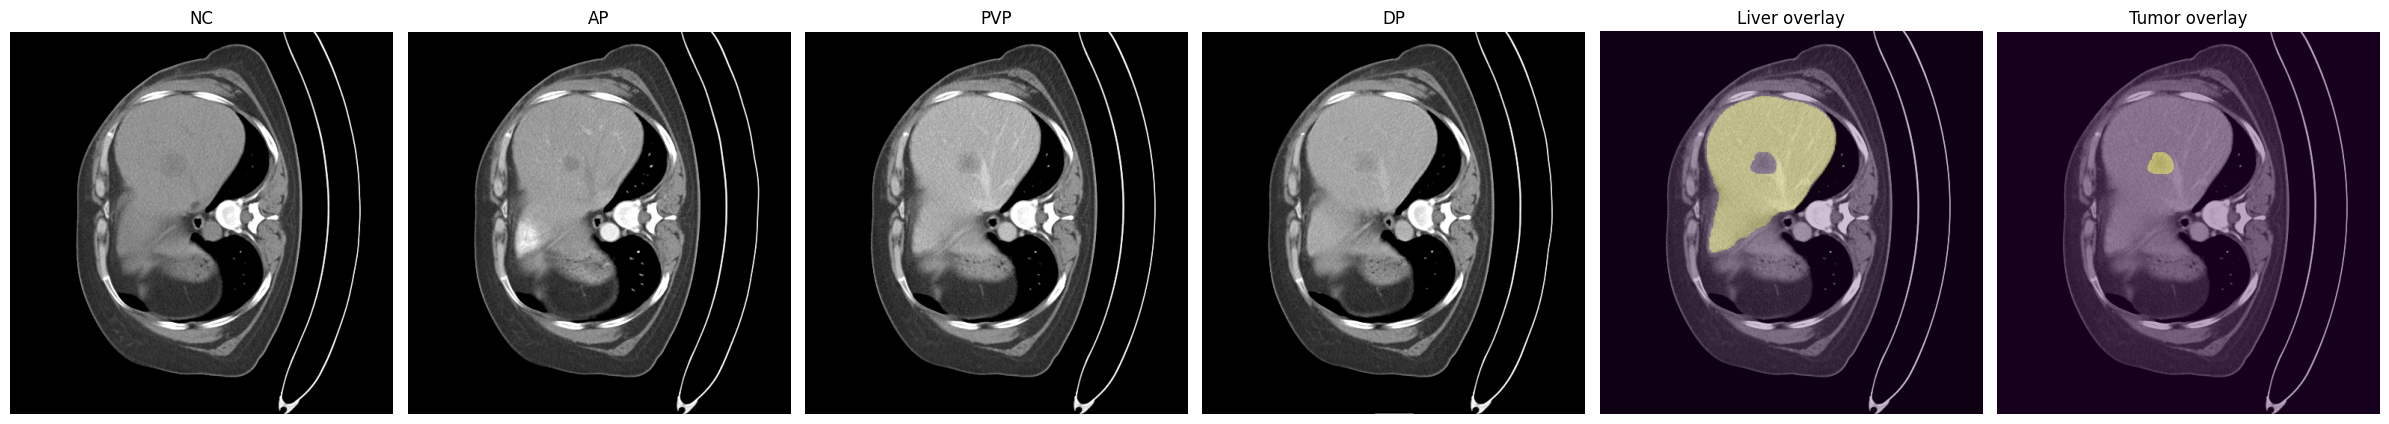

In [8]:
if len(tar_paths) == 0:
    print('No tar files available for visualization.')
else:
    visualize_sample_patient(tar_paths[0])


## 3. Build Safe Reusable Multi-Class Cache from 50 TAR Files

This cache now includes a **manifest** so we do not accidentally reuse stale or incompatible cached slices from an older notebook version.

Each `.npz` contains:

- `image`: `(4, H, W)` in phase order `[NC, AP, PVP, DP]`
- `mask`: `(H, W)` with classes `0=background, 1=liver, 2=tumor`
- `present`: which phases are present
- `has_tumor`: whether the selected slice contains tumor
- `patient_id`, `slice_idx`

The cache converts raw patient TAR files into reusable 2D multi-phase training slices. This is the key preprocessing stage that makes the later training loop faster, more repeatable, and easier to debug.


### Cache Manifest and Cache Validation Logic

This cell defines the cache versioning and manifest system used to safely reuse preprocessed data. By storing metadata such as image size, phase order, and selected TAR files, the notebook avoids accidentally training on stale or incompatible cached slices.

In [ ]:
CACHE_VERSION = 3
#Describe the cache configuration so stale cached slices can be detected safely.
def expected_cache_manifest(selected_tars):
    return {
        'cache_version': CACHE_VERSION,
        'img_size': IMG_SIZE,
        'phase_order': PHASE_ORDER,
        'max_tars': len(selected_tars),
        'tar_names': [os.path.basename(p) for p in selected_tars],
        'num_classes': NUM_CLASSES,
        'mask_definition': '0=background,1=liver,2=tumor',
    }


#Check whether the existing cache matches the current preprocessing settings.
def cache_is_valid(selected_tars):
    if not os.path.exists(CACHE_MANIFEST_PATH):
        return False
    try:
        with open(CACHE_MANIFEST_PATH, 'r') as f:
            manifest = json.load(f)
    except Exception:
        return False
    return manifest == expected_cache_manifest(selected_tars)

#Delete old cached files before rebuilding the slice cache.
def clear_cache_dir(cache_dir):
    if os.path.exists(cache_dir):
        for name in os.listdir(cache_dir):
            path = os.path.join(cache_dir, name)
            if os.path.isfile(path):
                os.remove(path)
            else:
                shutil.rmtree(path)
    ensure_dir(cache_dir)


#Convert raw patient volumes into reusable multi-phase 2D training slices.
def build_multiphase_cache(selected_tars, out_dir=MULTI_CACHE):
    ensure_dir(out_dir)
    ensure_dir(EXTRACT_ROOT)

    patient_slice_counts = {}
    usable_patients = 0
    failed_patients = []

    for i, tar_path in enumerate(selected_tars, start=1):
        patient_path = None
        try:
            patient_name, patient_path = extract_one_tar(tar_path)
            info = group_patient_files(patient_path)

            if info['tumor_mask'] is None or info['liver_mask'] is None:
                print(f'[{i:02d}] {patient_name}: missing required masks, skipping')
                failed_patients.append((patient_name, 'missing_masks'))
                continue

            phase_vols = {phase: load_volume(path) for phase, path in info['phase_map'].items()}
            if len(phase_vols) == 0:
                print(f'[{i:02d}] {patient_name}: no phase images found, skipping')
                failed_patients.append((patient_name, 'no_phases'))
                continue

            tumor_mask = load_volume(info['tumor_mask']).astype(np.uint8)
            liver_mask = load_volume(info['liver_mask']).astype(np.uint8)
            ok, ref_shape = validate_case_geometry(phase_vols, tumor_mask, liver_mask)
            if not ok:
                print(f'[{i:02d}] {patient_name}: geometry mismatch, skipping')
                failed_patients.append((patient_name, 'geometry_mismatch'))
                continue

            multiclass_mask = build_multiclass_mask(liver_mask, tumor_mask)
            present = [1 if p in phase_vols else 0 for p in PHASE_ORDER]
            slice_ids = select_slice_indices(multiclass_mask)
            saved_here = 0

            normalized_phase_vols = {phase: normalize_ct(vol) for phase, vol in phase_vols.items()}

            for z in slice_ids:
                img_stack = []
                for phase in PHASE_ORDER:
                    if phase in normalized_phase_vols:
                        img2d = resize_2d(normalized_phase_vols[phase][:, :, z], IMG_SIZE, is_mask=False)
                    else:
                        img2d = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)
                    img_stack.append(img2d)

                img_stack = np.stack(img_stack, axis=0).astype(np.float32)
                seg2d = resize_2d(multiclass_mask[:, :, z], IMG_SIZE, is_mask=True)
                has_tumor = int(np.any(seg2d == 2))

                save_path = os.path.join(out_dir, f'{patient_name}_z{z:03d}.npz')
                np.savez_compressed(
                    save_path,
                    image=img_stack,
                    mask=seg2d.astype(np.uint8),
                    present=np.array(present, dtype=np.uint8),
                    has_tumor=np.array([has_tumor], dtype=np.uint8),
                    patient_id=patient_name,
                    slice_idx=np.array([z], dtype=np.int32),
                )
                saved_here += 1

            if saved_here > 0:
                patient_slice_counts[patient_name] = saved_here
                usable_patients += 1
                print(f'[{i:02d}] {patient_name}: saved {saved_here} slices | present={present}')
            else:
                print(f'[{i:02d}] {patient_name}: no slices saved')
                failed_patients.append((patient_name, 'no_slices_saved'))

        except Exception as e:
            print(f'[{i:02d}] Error for {tar_path}: {e}')
            failed_patients.append((os.path.basename(tar_path), str(e)))
        finally:
            cleanup_patient(patient_path)

    manifest = expected_cache_manifest(selected_tars)
    with open(CACHE_MANIFEST_PATH, 'w') as f:
        json.dump(manifest, f, indent=2)

    print('\nCache complete.')
    print('Usable patients    :', usable_patients)
    print('Total cached slices:', sum(patient_slice_counts.values()))
    print('Failed patients    :', len(failed_patients))

    if failed_patients:
        print('\nFirst 10 failures:')
        for item in failed_patients[:10]:
            print(' ', item)

    return patient_slice_counts


### Multi-Phase Cache Construction

This cell checks whether a valid cache already exists. If not, it rebuilds the cache from the selected TAR files and stores each training slice as a reusable `.npz` file. This preprocessing step makes later experimentation faster, safer, and easier to reproduce.

In [10]:
print('Cache manifest path:', CACHE_MANIFEST_PATH)

if not cache_is_valid(tar_paths):
    print('Cache manifest missing or stale. Rebuilding cache...')
    clear_cache_dir(MULTI_CACHE)
    patient_slice_counts = build_multiphase_cache(tar_paths, MULTI_CACHE)
else:
    existing = [f for f in os.listdir(MULTI_CACHE) if f.endswith('.npz')]
    print('Valid cache already exists. Skipping rebuild.')
    print('Cached slice files:', len(existing))


Cache manifest path: /content/harvard_multiphase_work/processed_cache_50_multiclass/multiphase_mc_slices_50/cache_manifest.json
Cache manifest missing or stale. Rebuilding cache...
[01] 230218a1: saved 17 slices | present=[1, 1, 1, 1]
[02] 230218a10: saved 14 slices | present=[1, 1, 1, 1]
[03] 230218a2: saved 26 slices | present=[1, 1, 1, 1]
[04] 230218a3: saved 13 slices | present=[1, 1, 1, 1]
[05] 230218a4: saved 14 slices | present=[1, 1, 1, 1]
[06] 230218a5: saved 30 slices | present=[1, 1, 1, 1]
[07] 230218a6: saved 16 slices | present=[1, 1, 1, 1]
[08] 230218a7: saved 12 slices | present=[1, 1, 1, 1]
[09] 230218a8: saved 30 slices | present=[1, 1, 1, 1]
[10] 230218a9: saved 30 slices | present=[1, 1, 1, 1]
[11] 230218b1: saved 20 slices | present=[1, 1, 1, 1]
[12] 230218b10: saved 14 slices | present=[1, 1, 1, 1]
[13] 230218b2: saved 20 slices | present=[1, 1, 1, 1]
[14] 230218b3: saved 18 slices | present=[1, 1, 1, 1]
[15] 230218b4: saved 16 slices | present=[1, 1, 1, 1]
[16] 23

### Cache Inspection and Verification

This cell inspects the generated cache files and prints the shape and metadata of one sample cached slice. It verifies that the cached data contains the expected image tensor, segmentation mask, phase presence indicators, and patient information.

In [11]:
npz_files = sorted([os.path.join(MULTI_CACHE, f) for f in os.listdir(MULTI_CACHE) if f.endswith('.npz')])
print('Cached slice files:', len(npz_files))

if npz_files:
    sample = np.load(npz_files[0], allow_pickle=True)
    print('image shape :', sample['image'].shape)
    print('mask shape  :', sample['mask'].shape)
    print('present     :', sample['present'])
    print('has_tumor   :', sample['has_tumor'])
    print('patient id  :', sample['patient_id'])
    print('slice idx   :', sample['slice_idx'])
    print('mask labels :', np.unique(sample['mask']))

Cached slice files: 1042
image shape : (4, 256, 256)
mask shape  : (256, 256)
present     : [1 1 1 1]
has_tumor   : [0]
patient id  : 230218a10
slice idx   : [59]
mask labels : [0 1]


## Dataset Class and Patient-Wise Train/Validation/Test Split

This cell defines the PyTorch dataset used to load cached multi-phase slices during training and evaluation. It also supports lightweight augmentation and phase dropout. The split is performed patient-wise to prevent leakage between training and testing data.

In [ ]:
#Load cached multi-phase 2D slices and apply lightweight training augmentation.
class MultiPhaseNPZDataset(Dataset):
    def __init__(self, files, phase_dropout_prob=0.0, augment=False):
        self.files = files
        self.phase_dropout_prob = phase_dropout_prob
        self.augment = augment

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = np.load(self.files[idx], allow_pickle=True)
        image = data['image'].astype(np.float32)
        mask = data['mask'].astype(np.int64)
        present = data['present'].astype(np.float32)
        patient_id = str(data['patient_id'])
        slice_idx = int(data['slice_idx'][0])
        has_tumor = int(data['has_tumor'][0])

        if self.phase_dropout_prob > 0:
            keep = present.copy()
            for c in range(image.shape[0]):
                if keep[c] > 0 and random.random() < self.phase_dropout_prob:
                    keep[c] = 0.0
            if keep.sum() == 0:
                available = np.where(present > 0)[0]
                if len(available) > 0:
                    keep[random.choice(available)] = 1.0
            image = image * keep[:, None, None]
            present = keep

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.long)

        if self.augment:
            if random.random() > 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask.unsqueeze(0)).squeeze(0)
            if random.random() > 0.5:
                image = TF.vflip(image)
                mask = TF.vflip(mask.unsqueeze(0)).squeeze(0)
            if random.random() > 0.5:
                angle = random.choice([90, 180, 270])
                image = TF.rotate(image, angle)
                mask = TF.rotate(mask.unsqueeze(0), angle, interpolation=TF.InterpolationMode.NEAREST).squeeze(0)

        return {
            'image': image,
            'mask': mask,
            'present': torch.tensor(present, dtype=torch.float32),
            'patient_id': patient_id,
            'slice_idx': slice_idx,
            'has_tumor': has_tumor,
        }


#Create leak-safe train/val/test splits by grouping slices at the patient level.
def split_files_by_patient(npz_files, val_frac=VAL_FRAC, test_frac=TEST_FRAC, seed=SEED):
    patient_to_files = defaultdict(list)
    patient_has_tumor = defaultdict(int)
    for f in npz_files:
        data = np.load(f, allow_pickle=True)
        pid = str(data['patient_id'])
        patient_to_files[pid].append(f)
        patient_has_tumor[pid] = max(patient_has_tumor[pid], int(data['has_tumor'][0]))

    patients = sorted(patient_to_files.keys())
    if len(patients) < 3:
        raise RuntimeError(f'Need at least 3 patients for train/val/test split, found {len(patients)}')

    rng = random.Random(seed)
    tumor_patients = [p for p in patients if patient_has_tumor[p] == 1]
    non_tumor_patients = [p for p in patients if patient_has_tumor[p] == 0]
    rng.shuffle(tumor_patients)
    rng.shuffle(non_tumor_patients)

    def assign_group(group_patients):
        n_group = len(group_patients)
        if n_group == 0:
            return [], [], []
        n_test = int(round(n_group * test_frac))
        n_val = int(round(n_group * val_frac))
        if n_group >= 3:
            n_test = max(1, n_test)
            n_val = max(1, n_val)
        while n_test + n_val >= n_group and (n_test > 0 or n_val > 0):
            if n_test >= n_val and n_test > 0:
                n_test -= 1
            elif n_val > 0:
                n_val -= 1
        test_group = group_patients[:n_test]
        val_group = group_patients[n_test:n_test + n_val]
        train_group = group_patients[n_test + n_val:]
        return train_group, val_group, test_group

    train_t, val_t, test_t = assign_group(tumor_patients)
    train_n, val_n, test_n = assign_group(non_tumor_patients)

    train_patients = set(train_t + train_n)
    val_patients = set(val_t + val_n)
    test_patients = set(test_t + test_n)

    for split_name, split_patients in [('train', train_patients), ('val', val_patients), ('test', test_patients)]:
        if len(split_patients) == 0:
            raise RuntimeError(f'{split_name} split is empty. Adjust split fractions or cache more patients.')

    train_files, val_files, test_files = [], [], []
    for pid, files in patient_to_files.items():
        if pid in test_patients:
            test_files.extend(files)
        elif pid in val_patients:
            val_files.extend(files)
        else:
            train_files.extend(files)

    overlap = set(train_patients) & set(val_patients) | set(train_patients) & set(test_patients) | set(val_patients) & set(test_patients)
    assert len(overlap) == 0, f'Patient leakage detected: {overlap}'

    def split_summary(split_patients):
        return sum(patient_has_tumor[p] for p in split_patients), len(split_patients)

    train_tumor_pts, train_total_pts = split_summary(train_patients)
    val_tumor_pts, val_total_pts = split_summary(val_patients)
    test_tumor_pts, test_total_pts = split_summary(test_patients)
    print(f'Tumor-positive patients | train={train_tumor_pts}/{train_total_pts} | val={val_tumor_pts}/{val_total_pts} | test={test_tumor_pts}/{test_total_pts}')

    return train_files, val_files, test_files, sorted(train_patients), sorted(val_patients), sorted(test_patients)


train_files, val_files, test_files, train_patients, val_patients, test_patients = split_files_by_patient(npz_files)

print('Train patients:', len(train_patients), train_patients)
print('Val patients  :', len(val_patients), val_patients)
print('Test patients :', len(test_patients), test_patients)
print('Train slices  :', len(train_files))
print('Val slices    :', len(val_files))
print('Test slices   :', len(test_files))

train_ds = MultiPhaseNPZDataset(train_files, phase_dropout_prob=(PHASE_DROPOUT_PROB if MODEL_VARIANT == 'dependency' else 0.0), augment=True)
val_ds = MultiPhaseNPZDataset(val_files, phase_dropout_prob=0.0, augment=False)
test_ds = MultiPhaseNPZDataset(test_files, phase_dropout_prob=0.0, augment=False)
train_has_tumor = [int(np.load(f, allow_pickle=True)['has_tumor'][0]) for f in train_files]

sample_weights = [4.0 if flag == 1 else 1.0 for flag in train_has_tumor]
train_sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

num_tumor_pos = sum(train_has_tumor)
num_tumor_neg = len(train_has_tumor) - num_tumor_pos

print('Tumor-positive train slices:', num_tumor_pos)
print('Tumor-negative train slices:', num_tumor_neg)


Tumor-positive patients | train=34/34 | val=8/8 | test=8/8
Train patients: 34 ['230218a1', '230218a10', '230218a2', '230218a5', '230218a6', '230218a7', '230218a8', '230218b1', '230218b3', '230218b4', '230218b5', '230218b7', '230218b8', '230218c1', '230218c3', '230218c5', '230218c8', '230312a1', '230312a11', '230312a13', '230312a14', '230312a15', '230312a2', '230312a3', '230312a4', '230312a7', '230312a8', '230312a9', '230408a1', '230408a11', '230408a13', '230408a3', '230408a4', '230408a5']
Val patients  : 8 ['230218a3', '230218b2', '230218b6', '230218c10', '230312a10', '230312a12', '230312a5', '230312a6']
Test patients : 8 ['230218a4', '230218a9', '230218b10', '230218b9', '230218c4', '230218c6', '230218c7', '230408a12']
Train slices  : 721
Val slices    : 153
Test slices   : 168
Tumor-positive train slices: 402
Tumor-negative train slices: 319


## Sample Visualization from the Prepared Dataset

This cell displays a few examples from the prepared dataset, including input images and corresponding masks. It provides a quick qualitative check that the cached slices are loading correctly and that the data being fed to the model is sensible.

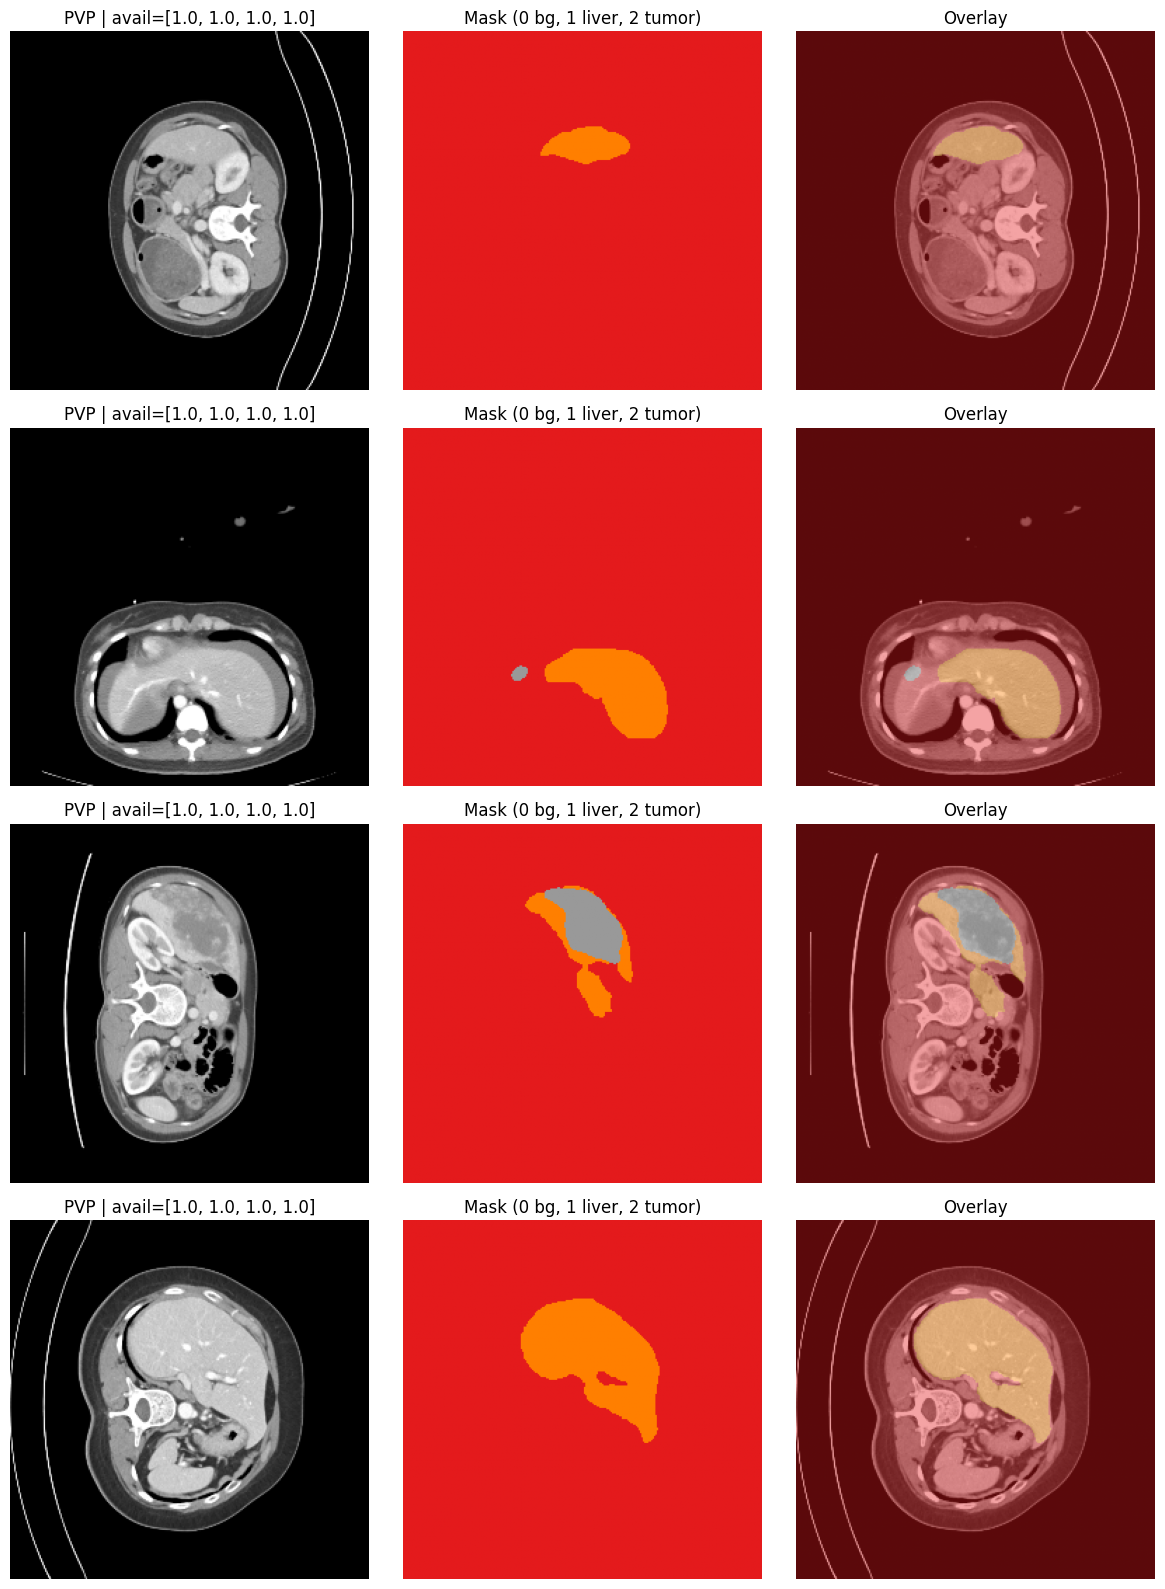

In [13]:
def plot_samples(dataset, n=4):
    fig, axes = plt.subplots(n, 3, figsize=(12, n * 4))
    cmap_mask = plt.get_cmap('Set1', 3)

    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    step = max(1, len(dataset) // n)
    for i in range(n):
        item = dataset[min(i * step, len(dataset) - 1)]
        img = item['image'][2].numpy()
        msk = item['mask'].numpy()

        axes[i, 0].imshow(img, cmap='gray')
        axes[i, 0].set_title(f'PVP | avail={item["present"].tolist()}')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(msk, cmap=cmap_mask, vmin=0, vmax=2)
        axes[i, 1].set_title('Mask (0 bg, 1 liver, 2 tumor)')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(img, cmap='gray')
        axes[i, 2].imshow(msk, cmap=cmap_mask, alpha=0.4, vmin=0, vmax=2)
        axes[i, 2].set_title('Overlay')
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()


plot_samples(train_ds, n=min(4, len(train_ds)))

### Models

This cell defines the segmentation models used in the notebook. It includes the attention-based components and the full network architectures for both the baseline attention U-Net and the dependency-aware variant. These models are designed for multi-class liver and tumor segmentation using four-phase CT input.

In [ ]:
#Gate skip features so the decoder focuses on the most relevant spatial signals.

class AttentionGate(nn.Module):
    def __init__(self, g_channels, x_channels, inter_channels):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(g_channels, inter_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(inter_channels),
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(x_channels, inter_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(inter_channels),
        )
        self.psi = nn.Sequential(
            nn.Conv2d(inter_channels, 1, kernel_size=1, bias=False),
            nn.BatchNorm2d(1),
            nn.Sigmoid(),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi


#Basic convolutional feature extractor used throughout the encoder and decoder.
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)



#Downsampling path that collects multi-scale features for segmentation.
class Encoder(nn.Module):
    def __init__(self, in_ch, features):
        super().__init__()
        self.blocks = nn.ModuleList()
        self.pools = nn.ModuleList()
        for f in features:
            self.blocks.append(ConvBlock(in_ch, f))
            self.pools.append(nn.MaxPool2d(2))
            in_ch = f

    def forward(self, x):
        skips = []
        for block, pool in zip(self.blocks, self.pools):
            x = block(x)
            skips.append(x)
            x = pool(x)
        return x, skips


#Upsampling path that combines coarse context with attention-filtered skip connections.

class AttentionDecoder(nn.Module):
    def __init__(self, features):
        super().__init__()
        self.ups = nn.ModuleList()
        self.attn_gates = nn.ModuleList()
        self.blocks = nn.ModuleList()
        for i in range(len(features) - 1):
            ch = features[i + 1]
            self.ups.append(nn.ConvTranspose2d(features[i], ch, kernel_size=2, stride=2))
            self.attn_gates.append(AttentionGate(g_channels=ch, x_channels=ch, inter_channels=max(ch // 2, 1)))
            self.blocks.append(ConvBlock(features[i], ch))

    def forward(self, x, skips):
        skips = skips[::-1]
        for up, attn, block, skip in zip(self.ups, self.attn_gates, self.blocks, skips):
            x = up(x)
            if x.shape[2:] != skip.shape[2:]:
                x = TF.resize(x, size=skip.shape[2:])
            skip = attn(g=x, x=skip)
            x = torch.cat([skip, x], dim=1)
            x = block(x)
        return x


#Main baseline segmentation model used for the reported results in this notebook.
class BaselineAttentionUNet(nn.Module):
    def __init__(self, in_channels=IN_CHANNELS, num_classes=NUM_CLASSES, features=[64, 128, 256, 512]):
        super().__init__()
        self.encoder = Encoder(in_channels, features)
        self.bottleneck = ConvBlock(features[-1], features[-1] * 2)
        decoder_features = [features[-1] * 2] + features[::-1]
        self.decoder = AttentionDecoder(decoder_features)
        self.head = nn.Conv2d(features[0], num_classes, kernel_size=1)

    def forward(self, image, present=None):
        x, skips = self.encoder(image)
        x = self.bottleneck(x)
        x = self.decoder(x, skips)
        logits = self.head(x)
        return {'logits': logits}


#Reusable per-phase encoder for the dependency-aware model variant.
class SharedPhaseEncoder(nn.Module):
    def __init__(self, base_features=[32, 64, 128]):
        super().__init__()
        self.encoder = Encoder(1, base_features)
        self.bottleneck = ConvBlock(base_features[-1], base_features[-1] * 2)

    def forward(self, x):
        feat, skips = self.encoder(x)
        feat = self.bottleneck(feat)
        return feat, skips


#Alternative model that fuses phase-specific features with simple dependency-aware interactions.
class DependencyAttentionUNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, num_phases=4, base_features=[32, 64, 128]):
        super().__init__()
        self.num_phases = num_phases
        self.phase_encoder = SharedPhaseEncoder(base_features=base_features)
        fusion_ch = base_features[-1] * 2
        self.phase_gate = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(fusion_ch, fusion_ch // 2, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(fusion_ch // 2, 1, 1),
            nn.Sigmoid(),
        )
        self.context_proj = nn.Conv2d(fusion_ch, fusion_ch, kernel_size=1)
        decoder_features = [fusion_ch] + base_features[::-1]
        self.decoder = AttentionDecoder(decoder_features)
        self.head = nn.Conv2d(base_features[0], num_classes, kernel_size=1)

    def forward(self, image, present=None):
        phase_feats, phase_skips, phase_gates = [], [], []
        for p in range(self.num_phases):
            feat, skips = self.phase_encoder(image[:, p:p+1])
            gate = self.phase_gate(feat)
            if present is not None:
                gate = gate * present[:, p].view(-1, 1, 1, 1)
            phase_feats.append(feat)
            phase_skips.append(skips)
            phase_gates.append(gate)

        fused_feat = 0
        fused_skips = [0 for _ in range(len(phase_skips[0]))]
        denom = 1e-6
        for idx, feat in enumerate(phase_feats):
            gate = phase_gates[idx]
            fused_feat = fused_feat + feat * gate
            denom = denom + gate
            for s_idx, skip in enumerate(phase_skips[idx]):
                fused_skips[s_idx] = fused_skips[s_idx] + skip * gate
        fused_feat = fused_feat / denom
        fused_skips = [skip / denom for skip in fused_skips]

        pair_sum = 0
        pair_weight_sum = 0
        for i in range(self.num_phases):
            for j in range(i + 1, self.num_phases):
                pair = phase_feats[i] * phase_feats[j]
                if present is not None:
                    pair_weight = (present[:, i] * present[:, j]).view(-1, 1, 1, 1)
                    pair = pair * pair_weight
                    pair_weight_sum = pair_weight_sum + pair_weight
                else:
                    pair_weight_sum = pair_weight_sum + 1.0
                pair_sum = pair_sum + pair
        fused_feat = fused_feat + self.context_proj(pair_sum / torch.clamp(pair_weight_sum, min=1e-6))

        x = self.decoder(fused_feat, fused_skips)
        logits = self.head(x)
        return {'logits': logits}


model = BaselineAttentionUNet().to(DEVICE) if MODEL_VARIANT == 'baseline' else DependencyAttentionUNet().to(DEVICE)

params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('Model variant:', MODEL_VARIANT)
print('Model params :', f'{params:,}')
with torch.no_grad():
    dummy_x = torch.randn(2, IN_CHANNELS, IMG_SIZE, IMG_SIZE).to(DEVICE)
    dummy_p = torch.ones(2, IN_CHANNELS).to(DEVICE)
    out = model(dummy_x, present=dummy_p)
    print('Output shape :', out['logits'].shape)

Model variant: baseline
Model params : 31,388,907
Output shape : torch.Size([2, 3, 256, 256])


## Loss Function and Evaluation Metrics

This cell defines the weighted Dice-based loss and the metric computation used during training and evaluation. The objective places stronger emphasis on tumor performance while still tracking liver segmentation quality.

In [ ]:
#Dice-style loss with extra weight on tumor accuracy relative to liver.
class WeightedDiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        targets_oh = F.one_hot(targets, num_classes=logits.shape[1]).permute(0, 3, 1, 2).float()
        dims = (0, 2, 3)
        intersection = (probs * targets_oh).sum(dims)
        cardinality = (probs + targets_oh).sum(dims)
        dice = (2 * intersection + self.smooth) / (cardinality + self.smooth)
        fg_w = torch.tensor([0.3, 0.7], device=logits.device)
        return 1 - (dice[1:] * fg_w).sum()


#Blend cross-entropy and Dice so optimization handles both class imbalance and overlap quality.
class CombinedLoss(nn.Module):
    def __init__(self, class_weights=None):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=class_weights)
        self.dice = WeightedDiceLoss()

    def forward(self, logits, targets):
        return 0.4 * self.ce(logits, targets) + 0.6 * self.dice(logits, targets)

#Accumulate global intersection/prediction/target counts for dataset-level Dice computation.
def update_metric_sums(logits, targets, metric_sums):
    preds = logits.argmax(dim=1)

    pred_liver = (preds > 0).float()
    true_liver = (targets > 0).float()
    metric_sums['liver']['inter'] += float((pred_liver * true_liver).sum().item())
    metric_sums['liver']['pred'] += float(pred_liver.sum().item())
    metric_sums['liver']['true'] += float(true_liver.sum().item())

    pred_tumor = (preds == 2).float()
    true_tumor = (targets == 2).float()
    metric_sums['tumor']['inter'] += float((pred_tumor * true_tumor).sum().item())
    metric_sums['tumor']['pred'] += float(pred_tumor.sum().item())
    metric_sums['tumor']['true'] += float(true_tumor.sum().item())


def finalize_metric_sums(metric_sums, eps=1e-6):
    """Convert accumulated counts into final Dice scores for each target category."""
    scores = {}
    for name, sums in metric_sums.items():
        scores[name] = float((2 * sums['inter'] + eps) / (sums['pred'] + sums['true'] + eps))
    return scores



#Estimate class weights directly from the cached masks so CE reflects dataset imbalance.
def estimate_class_weights(files, num_classes=NUM_CLASSES):
    counts = np.zeros(num_classes, dtype=np.float64)
    for f in files:
        mask = np.load(f, allow_pickle=True)['mask']
        binc = np.bincount(mask.reshape(-1), minlength=num_classes)
        counts += binc
    counts = np.maximum(counts, 1.0)
    inv = counts.sum() / counts
    weights = inv / inv.sum()
    return torch.tensor(weights, dtype=torch.float32)


class_weights = estimate_class_weights(train_files).to(DEVICE)
criterion = CombinedLoss(class_weights=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=4, factor=0.5)

print('Loss   : weighted CE + tumor-weighted Dice')
print('CE class weights:', class_weights.detach().cpu().numpy().round(4).tolist())
print('Saving : best checkpoint by 0.3*liver + 0.7*tumor DSC')

Loss   : weighted CE + tumor-weighted Dice
CE class weights: [0.0038999998942017555, 0.07000000029802322, 0.9261000156402588]
Saving : best checkpoint by 0.3*liver + 0.7*tumor DSC


## Training Loop

This cell contains the training pipeline. It loads or initializes training history, saves checkpoints, tracks validation performance, and records liver and tumor Dice scores across epochs. This forms the core experimentation loop of the notebook.

In [ ]:
history_path = os.path.join(ARTIFACT_DIR, f'history_google50_{MODEL_VARIANT}.json')
latest_ckpt_path = os.path.join(ARTIFACT_DIR, f'checkpoint_google50_{MODEL_VARIANT}_latest.pt')
best_model_path = os.path.join(ARTIFACT_DIR, f'best_google50_{MODEL_VARIANT}.pt')

if os.path.exists(history_path):
    with open(history_path, 'r') as f:
        history = json.load(f)
    print('Resumed history from', history_path)
else:
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_liver': [],
        'val_liver': [],
        'train_tumor': [],
        'val_tumor': [],
    }
    print('Starting fresh history.')

if os.path.exists(latest_ckpt_path):
    model.load_state_dict(torch.load(latest_ckpt_path, map_location=DEVICE))
    print('Resumed model weights from', latest_ckpt_path)

epochs_done = len(history['train_loss'])
best_combined = max((0.3 * l + 0.7 * t for l, t in zip(history.get('val_liver', []), history.get('val_tumor', []))), default=0.0)


#Run the active model variant through a shared wrapper so the loop stays model-agnostic.
def forward_model(model, images, present):
    out = model(images, present=present)
    return out['logits'] if isinstance(out, dict) else out


#Execute one full training pass and return average loss plus global Dice metrics.

def train_one_epoch(model, loader, optimizer, criterion, device=DEVICE):
    model.train()
    total_loss = 0.0
    metric_sums = {
        'liver': {'inter': 0.0, 'pred': 0.0, 'true': 0.0},
        'tumor': {'inter': 0.0, 'pred': 0.0, 'true': 0.0},
    }

    for batch in tqdm(loader, desc='Train', leave=False):
        x = batch['image'].to(device)
        y = batch['mask'].to(device)
        present = batch['present'].to(device)

        optimizer.zero_grad()
        logits = forward_model(model, x, present)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        with torch.no_grad():
            update_metric_sums(logits, y, metric_sums)

    avg_loss = total_loss / max(len(loader), 1)
    avg_scores = finalize_metric_sums(metric_sums)
    return avg_loss, avg_scores


@torch.no_grad()

#Run validation or test evaluation without gradient updates.
def evaluate(model, loader, criterion, device=DEVICE):
    model.eval()
    total_loss = 0.0
    metric_sums = {
        'liver': {'inter': 0.0, 'pred': 0.0, 'true': 0.0},
        'tumor': {'inter': 0.0, 'pred': 0.0, 'true': 0.0},
    }

    for batch in tqdm(loader, desc='Eval', leave=False):
        x = batch['image'].to(device)
        y = batch['mask'].to(device)
        present = batch['present'].to(device)

        logits = forward_model(model, x, present)
        loss = criterion(logits, y)
        total_loss += loss.item()
        update_metric_sums(logits, y, metric_sums)

    avg_loss = total_loss / max(len(loader), 1)
    avg_scores = finalize_metric_sums(metric_sums)
    return avg_loss, avg_scores


print(f'Training for {NUM_EPOCHS} epochs on {DEVICE}...\n')
# The best checkpoint is chosen using validation Dice so the final test report is based on the strongest saved model.
for epoch in range(epochs_done + 1, NUM_EPOCHS + 1):
    tr_loss, tr_scores = train_one_epoch(model, train_loader, optimizer, criterion, device=DEVICE)
    va_loss, va_scores = evaluate(model, val_loader, criterion, device=DEVICE)

    combined = 0.3 * va_scores['liver'] + 0.7 * va_scores['tumor']
    scheduler.step(combined)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_liver'].append(tr_scores['liver'])
    history['val_liver'].append(va_scores['liver'])
    history['train_tumor'].append(tr_scores['tumor'])
    history['val_tumor'].append(va_scores['tumor'])

    with open(history_path, 'w') as f:
        json.dump(history, f)
    torch.save(model.state_dict(), latest_ckpt_path)

    saved = ''
    if combined > best_combined:
        best_combined = combined
        torch.save(model.state_dict(), best_model_path)
        saved = ' <- saved'

    print(
        f'Epoch {epoch:02d}/{NUM_EPOCHS} | '
        f'train loss {tr_loss:.4f} | val loss {va_loss:.4f} | '
        f'liver DSC {va_scores["liver"]:.4f} | tumor DSC {va_scores["tumor"]:.4f}'
        f'{saved}'
    )

print('\nBest combined validation score:', best_combined)
print('Best model saved to:', best_model_path)

Starting fresh history.
Training for 20 epochs on cuda...



Epoch 01/20 | train loss 0.7708 | val loss 0.7890 | liver DSC 0.5153 | tumor DSC 0.0317 <- saved


Epoch 02/20 | train loss 0.6958 | val loss 0.7704 | liver DSC 0.6770 | tumor DSC 0.0684 <- saved


Epoch 03/20 | train loss 0.6476 | val loss 1.0342 | liver DSC 0.6887 | tumor DSC 0.0545


Epoch 04/20 | train loss 0.6204 | val loss 0.6703 | liver DSC 0.8270 | tumor DSC 0.2162 <- saved


...

Epoch 16/20 | train loss 0.2869 | val loss 0.5434 | liver DSC 0.9161 | tumor DSC 0.4076


Epoch 17/20 | train loss 0.2690 | val loss 0.5590 | liver DSC 0.9064 | tumor DSC 0.5609


Epoch 18/20 | train loss 0.2565 | val loss 0.5340 | liver DSC 0.9115 | tumor DSC 0.5930


Epoch 19/20 | train loss 0.2562 | val loss 0.5341 | liver DSC 0.8872 | tumor DSC 0.6007


Epoch 20/20 | train loss 0.2327 | val loss 0.5196 | liver DSC 0.8913 | tumor DSC 0.5619

Best combined validation score: 0.6999570153628611
Best model saved to: /content/harvard_multiphase_work/processed_cache_50_multiclass/training_artifacts/best_google50_baseline.pt


## Training and Validation Curves

This cell plots the training history, including loss and Dice curves. These plots help assess convergence behavior, overfitting risk, and whether the model is improving consistently over time.

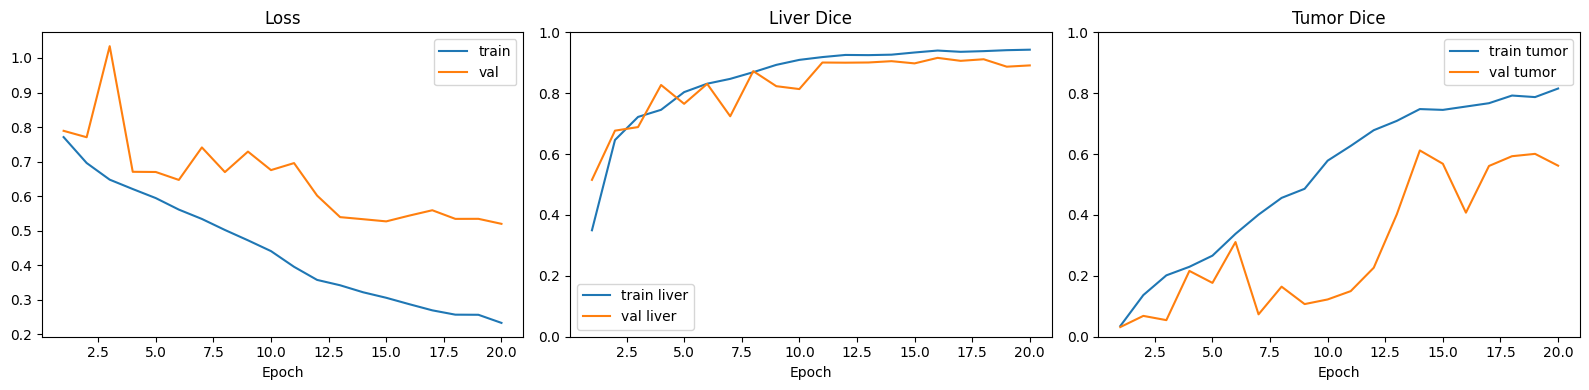

In [17]:
def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(16, 4))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, history['train_loss'], label='train')
    plt.plot(epochs, history['val_loss'], label='val')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs, history['train_liver'], label='train liver')
    plt.plot(epochs, history['val_liver'], label='val liver')
    plt.title('Liver Dice')
    plt.xlabel('Epoch')
    plt.ylim(0, 1)
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs, history['train_tumor'], label='train tumor')
    plt.plot(epochs, history['val_tumor'], label='val tumor')
    plt.title('Tumor Dice')
    plt.xlabel('Epoch')
    plt.ylim(0, 1)
    plt.legend()

    plt.tight_layout()
    plt.show()


plot_history(history)

## Final Test Evaluation

This cell reloads the best saved model checkpoint and evaluates it on the held-out test set. The reported test loss, liver Dice, and tumor Dice represent the main quantitative results for this notebook submission.

In [18]:
best_model = BaselineAttentionUNet().to(DEVICE) if MODEL_VARIANT == 'baseline' else DependencyAttentionUNet().to(DEVICE)
best_model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

test_loss, test_scores = evaluate(best_model, test_loader, criterion, device=DEVICE)

print('=' * 55)
print(f'  GOOGLE-DRIVE HARVARD {MODEL_VARIANT.upper()} RESULTS (Test Set)')
print('=' * 55)
print(f'  Test Loss  : {test_loss:.4f}')
print(f'  Liver DSC  : {test_scores["liver"]:.4f}')
print(f'  Tumor DSC  : {test_scores["tumor"]:.4f}')
print('=' * 55)

summary = {
    'model_variant': MODEL_VARIANT,
    'test_loss': float(test_loss),
    'test_liver_dice': float(test_scores['liver']),
    'test_tumor_dice': float(test_scores['tumor']),
    'train_patients': train_patients,
    'val_patients': val_patients,
    'test_patients': test_patients,
}
with open(os.path.join(ARTIFACT_DIR, f'test_summary_google50_{MODEL_VARIANT}.json'), 'w') as f:
    json.dump(summary, f, indent=2)

  GOOGLE-DRIVE HARVARD BASELINE RESULTS (Test Set)
  Test Loss  : 0.6712
  Liver DSC  : 0.8896
  Tumor DSC  : 0.5287


## Qualitative Prediction Visualization

This cell visualizes model predictions alongside the input image and ground-truth mask. These examples help assess whether the quantitative scores match the actual visual segmentation quality and provide an intuitive check on model behavior.

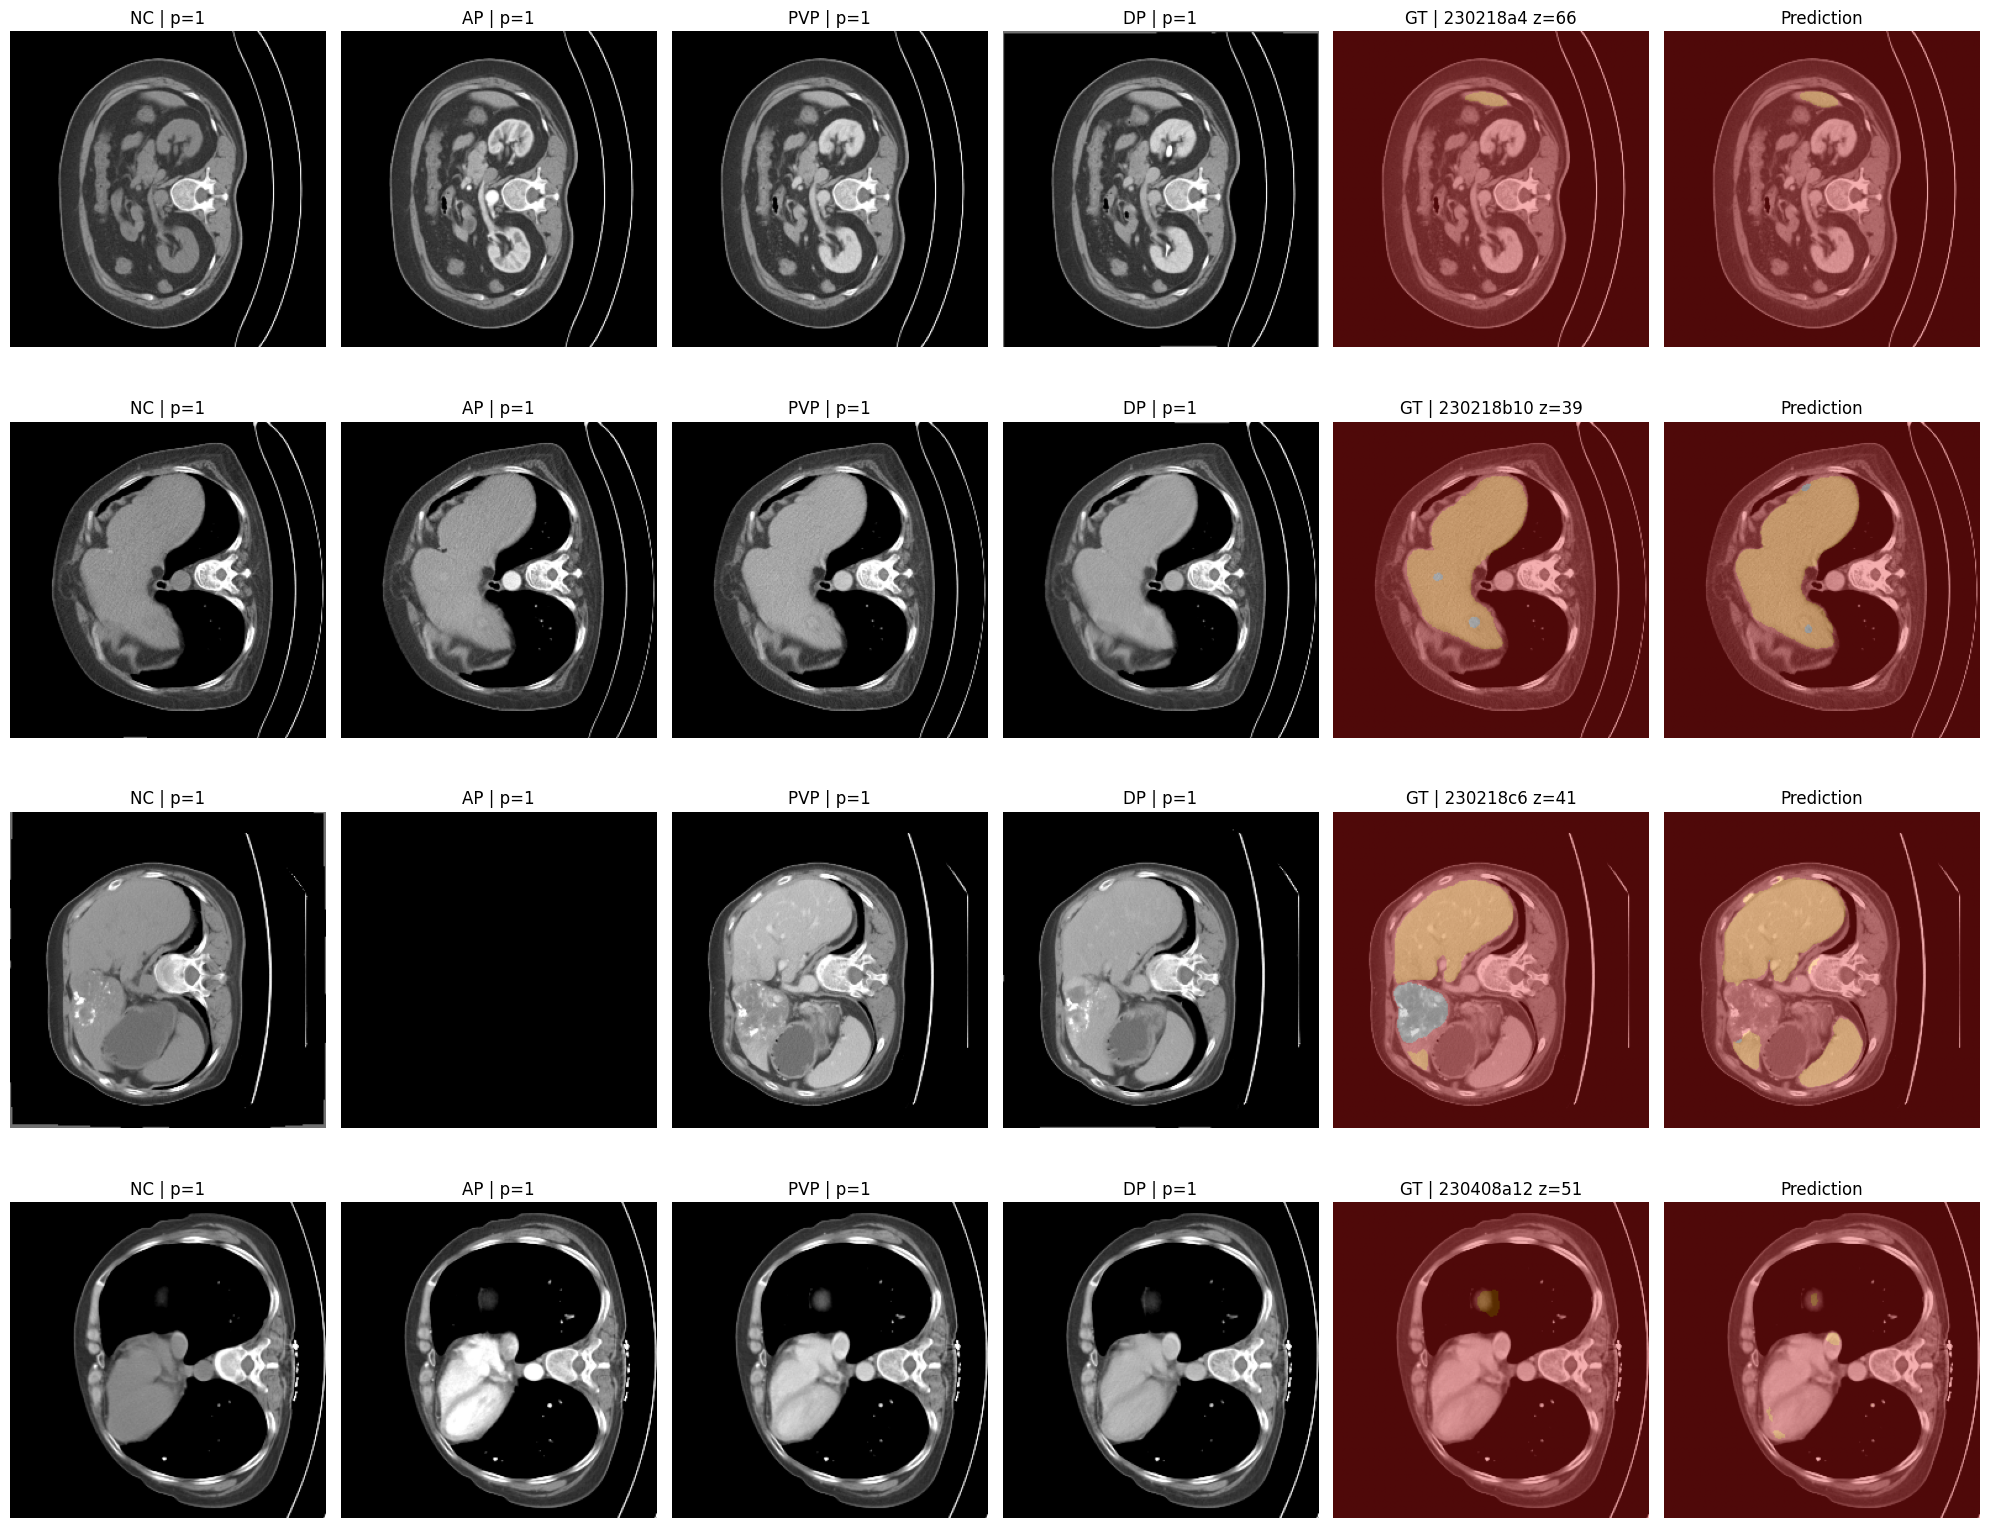

In [ ]:
@torch.no_grad()


#Show qualitative predictions so metric values can be checked against visual segmentation behavior.
def visualize_predictions(model, dataset, num_samples=4, device=DEVICE):
    model.eval()
    idxs = np.linspace(0, max(0, len(dataset) - 1), num=min(num_samples, len(dataset)), dtype=int)
    cmap = plt.get_cmap('Set1', 3)

    fig, axes = plt.subplots(len(idxs), 6, figsize=(20, 4 * len(idxs)))
    if len(idxs) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, idx in enumerate(idxs):
        item = dataset[idx]
        x = item['image'][None].to(device)
        y = item['mask'].cpu().numpy()
        present = item['present'][None].to(device)
        pid = item['patient_id']
        slice_idx = item['slice_idx']

        logits = forward_model(model, x, present)
        pred = logits.argmax(dim=1)[0].cpu().numpy()

        for c, phase in enumerate(PHASE_ORDER):
            axes[row, c].imshow(item['image'][c].cpu().numpy(), cmap='gray')
            axes[row, c].set_title(f'{phase.upper()} | p={int(item["present"][c].item())}')
            axes[row, c].axis('off')

        axes[row, 4].imshow(item['image'][2].cpu().numpy(), cmap='gray')
        axes[row, 4].imshow(y, cmap=cmap, alpha=0.35, vmin=0, vmax=2)
        axes[row, 4].set_title(f'GT | {pid} z={slice_idx}')
        axes[row, 4].axis('off')

        axes[row, 5].imshow(item['image'][2].cpu().numpy(), cmap='gray')
        axes[row, 5].imshow(pred, cmap=cmap, alpha=0.35, vmin=0, vmax=2)
        axes[row, 5].set_title('Prediction')
        axes[row, 5].axis('off')

    plt.tight_layout()
    plt.show()


visualize_predictions(best_model, test_ds, num_samples=min(4, len(test_ds)), device=DEVICE)

## 12. Current-Phase Submission Note:

Considering we just got hold of te harvard dataset, we implemented the basic functionality on our baseline and added these functionalities:

- used the 50 TAR files from Drive
-  all four phases in the dataset are being used
- trains **multi-class** liver/tumor segmentation
- tracks both liver Dice and tumor Dice
- uses a cache manifest to avoid stale cache mistakes
- improves training quality with stronger slice sampling and tumor oversampling
- supports a dependency-aware model without explicitly printing dependency scores yet (this will be done in the next phase)

***Some pointers for our implementation for the next phase:***

- explicit dependency-score outputs
- stronger controlled missing-phase ablations such as missing `AP` or missing `PVP`
- richer evaluation metrics beyond Dice, such as HD95 or VOE
- stronger dependency-aware fusion
